# Escuela Politecnica Nacional
- Nombre: Freddy Jimenez
- Fecha: 27/05/2026

In [ ]:
# !pip install pandas nltk scikit-learn sentence-transformers matplotlib seaborn

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------------------------------- -------- 7.9/9.9 MB 50.4 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.9 MB 22.9 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 18.2 MB/s  0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 35.3 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 8.1/8.1 MB 70.4 MB/s  0:00:00
   ---------------------------------------- 0.0/588.9 kB ? eta -:--:--
   ---------------------------------------- 588.9/588.9 kB 28.6 MB/s  0:00:00
   ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
   ---------------------------------------- 10.8/10.8 MB 64.1 MB/s  0:00:00
   ---------------------------------------- 0.0/668.2 kB ? eta -:--:--
   ---------------------------------------- 668.2/6


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

Descargar recursos de NLTK

In [10]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LabP5E004\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Cargar dataset desde carpeta data

In [ ]:
# Cargar archivos desde la carpeta 'data'
movies_df = pd.read_csv("data/rotten_tomatoes_movies.csv")
reviews_df = pd.read_csv("data/rotten_tomatoes_critic_reviews.csv")

# Muestra cantidad de datos cargados
print("Archivos cargados exitosamente")
print(f"Películas: {movies_df.shape}")
print(f"Críticas: {reviews_df.shape}")

Archivos cargados exitosamente
Películas: (17712, 22)
Críticas: (1130017, 8)


Cargar y optimizar dataset

In [13]:
# Mostrar columnas disponibles
print("\nColumnas en críticas:")
print(reviews_df.columns.tolist())
print("\nColumnas en películas:")
print(movies_df.columns.tolist())


Columnas en críticas:
['rotten_tomatoes_link', 'critic_name', 'top_critic', 'publisher_name', 'review_type', 'review_score', 'review_date', 'review_content']

Columnas en películas:
['rotten_tomatoes_link', 'movie_title', 'movie_info', 'critics_consensus', 'content_rating', 'genres', 'directors', 'authors', 'actors', 'original_release_date', 'streaming_release_date', 'runtime', 'production_company', 'tomatometer_status', 'tomatometer_rating', 'tomatometer_count', 'audience_status', 'audience_rating', 'audience_count', 'tomatometer_top_critics_count', 'tomatometer_fresh_critics_count', 'tomatometer_rotten_critics_count']


Unir y optimizar para memoria

In [ ]:
# Unir críticas con información de películas
df = reviews_df.merge(
    movies_df[['rotten_tomatoes_link', 'movie_title']], 
    on='rotten_tomatoes_link', 
    how='inner'
)

# Eliminar críticas vacías
df = df.dropna(subset=['review_content'])

print(f"Documentos después de unir: {len(df)} críticas")

# IMPORTANTE: Para no saturar memoria, tomar una muestra representativa
SAMPLE_SIZE = 10000  # Puedes ajustar: 5000, 10000, 20000

if len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=42)
    print(f"Se tomó una muestra de {SAMPLE_SIZE} documentos para optimizar memoria")
else:
    print(f"Usando todos los {len(df)} documentos")

print(f"Documentos finales: {len(df)}")

Documentos después de unir: 1064109 críticas
Se tomó una muestra de 10000 documentos para optimizar memoria
Documentos finales: 10000


Verificar balance del dataset

In [16]:
# Ver cuántas películas diferentes tenemos
unique_movies = df['movie_title'].nunique()
print(f"Películas únicas en la muestra: {unique_movies}")

# Ver distribución de críticas por película
reviews_per_movie = df.groupby('movie_title').size().sort_values(ascending=False)
print(f"\nTop 5 películas con más críticas:")
for movie, count in reviews_per_movie.head(5).items():
    print(f"   {movie}: {count} críticas")

# Mostrar ejemplo
print("\nEjemplo de crítica:")
print("-" * 60)
print(f"Película: {df.iloc[0]['movie_title']}")
print(f"Crítica: {df.iloc[0]['review_content'][:300]}...")

Películas únicas en la muestra: 5608

Top 5 películas con más críticas:
   Sicario: Day of the Soldado: 14 críticas
   Red Sparrow: 14 críticas
   Stuber: 13 críticas
   Spider-Man: Far From Home: 13 críticas
   Split: 12 críticas

Ejemplo de crítica:
------------------------------------------------------------
Película: Reality (Réalité)
Crítica: [A] mind-numbingly unfunny attempt to apply slippery dream logic to filmmaking....


# 1. PREPROCESAMIENTO DE TEXTOS

Función de preprocesamiento 

In [ ]:
# Limpia y normaliza texto para análisis
def preprocess_text(text):
    """
    Pipeline de preprocesamiento:
    - Minúsculas
    - Eliminar puntuación
    - Eliminar espacios redundantes
    - Eliminar stopwords
    """
    text = str(text).lower()  # Convierte a minúsculas
    text = re.sub(r'[^\w\s]', '', text)   # Elimina puntuación
    text = re.sub(r'\s+', ' ', text).strip()   # Elimina espacios extras
    text = ' '.join([word for word in text.split() if word not in stop_words]) # Quita stopwords
    return text

# Probar función con la crítica que viste
test = df.iloc[0]['review_content']
print(f"Original: {test[:100]}...")
print(f"\nProcesado: {preprocess_text(test)[:100]}...")

Original: [A] mind-numbingly unfunny attempt to apply slippery dream logic to filmmaking....

Procesado: mindnumbingly unfunny attempt apply slippery dream logic filmmaking...


Aplicar preprocesamiento a todos los documentos

In [ ]:
from tqdm import tqdm # Librería para barras de progreso
tqdm.pandas()  # Activa progreso en pandas

print("Aplicando preprocesamiento a 10,000 documentos...")

# progress_apply muestra barra de progreso mientras limpia textos
df['processed_text'] = df['review_content'].progress_apply(preprocess_text)
print("Preprocesamiento completado")

# Cuenta cuántos textos quedaron vacíos
empty_texts = (df['processed_text'] == '').sum()
print(f"Textos vacíos después del preprocesamiento: {empty_texts}")

# Elimina filas con texto vacío
if empty_texts > 0:
    df = df[df['processed_text'] != '']
    print(f"Documentos restantes: {len(df)}")

Aplicando preprocesamiento a 10,000 documentos...


100%|██████████| 9999/9999 [00:00<00:00, 34447.96it/s]

Preprocesamiento completado
Textos vacíos después del preprocesamiento: 0


# 2. GENERACIÓN DE EMBEDDINGS

In [ ]:
# Carga modelo preentrenado para convertir textos en vectores
print("Cargando modelo Sentence Transformers...")
model = SentenceTransformer('all-MiniLM-L6-v2') # Modelo ligero y eficaz
print("Modelo cargado correctamente")
print(f"Dimensiones del embedding: {model.get_sentence_embedding_dimension()}")

Cargando modelo Sentence Transformers...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5400.71it/s]


✅ Modelo cargado correctamente
Dimensiones del embedding: 384


Generar vectores para todos los documentos

In [ ]:
# Convierte todos los textos a vectores numéricos
print(f"Generando embeddings para {len(df)} documentos")

embeddings = model.encode(
    df['processed_text'].tolist(),  # Textos limpios a vector
    show_progress_bar=True,  # Muestra barra de progreso
    batch_size=64  # Procesa 64 textos por vez
)

print(f"Embeddings generados: {embeddings.shape}")  # (documentos, 384)
print(f"Memoria usada: {embeddings.nbytes / 1024**2:.2f} MB") # Espacio en RAM

Generando embeddings para 9999 documentos...
Esto tomará aproximadamente 2-3 minutos...


Batches: 100%|██████████| 157/157 [01:58<00:00,  1.32it/s]

Embeddings generados: (9999, 384)
Memoria usada: 14.65 MB


# 3. SISTEMA DE RECUPERACIÓN (SIMILITUD COSENO)

Función de búsqueda por similitud coseno

In [ ]:
# Busca documentos similares a la consulta del usuario
def search(query, k=5):
    """
    Busca los k documentos más relevantes para una consulta
    """
    # Limpia la pregunta del usuario
    query_processed = preprocess_text(query)
    
    # Convierte pregunta a vector
    query_embedding = model.encode([query_processed])
    
    # Calcula qué tan similares son los documentos
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    
    # Obtiene los k más similares (ordenados de mayor a menor)
    top_indices = np.argsort(similarities)[::-1][:k]
    
    # Arma la tabla de resultados
    results = []
    for rank, idx in enumerate(top_indices, 1):
        results.append({
            'ranking': rank,  # Puesto 1,2,3...
            'doc_id': idx,   # Identificador único
            'movie_title': df.iloc[idx]['movie_title'],  # Nombre película
            'review_fragment': df.iloc[idx]['review_content'][:200] + "...",  # Crítica corta
            'similarity': round(similarities[idx], 4)  # Puntaje de parecido
        })
    
    return pd.DataFrame(results)

Probar búsqueda

In [ ]:
# Prueba rápida del buscador con una consulta de ejemplo
query_test = "science fiction futuristic technology"
results_test = search(query_test, k=3)  # Busca top 3 resultados

print("PRUEBA DEL SISTEMA")
print(f"Consulta: {query_test}")
print("\nResultados:")
print(results_test.to_string(index=False)) # Muestra tabla sin números de fila

PRUEBA DEL SISTEMA
Consulta: science fiction futuristic technology

Resultados:
 ranking  doc_id    movie_title                                                                                                                                       review_fragment  similarity
       1    5025      Contagion                                                                                                                       No science fiction bulls**t!...      0.6027
       2    7460      Idiocracy A cautionary, sci-fi comedy which envisions a miserable dystopia half a millenia in the future where humanity has degenerated instead of advanced....      0.5245
       3    9366 The Terminator                                                      "TECH%u2022NOIR" indeed. He's a futuristic machine and this movie is pitch black with menace....      0.4989


# 4. BENCHMARK DE CONSULTAS

Definir las 8 consultas obligatorias

In [ ]:
# Las 8 consultas obligatorias del examen
queries = [
    "science fiction movie with advanced technology",
    "romantic story with emotional relationships",
    "action movie with intense fight scenes",
    "horror film that creates fear and suspense",
    "visually impressive movie with weak storyline",
    "emotionally moving performance by the lead actor",
    "predictable plot but entertaining experience",
    "movie praised by critics but unpopular with audiences"
]

# Muestra lista numerada de consultas
print(f"{len(queries)} consultas cargadas")
for i, q in enumerate(queries, 1):
    print(f"{i}. {q}")

8 consultas cargadas
1. science fiction movie with advanced technology
2. romantic story with emotional relationships
3. action movie with intense fight scenes
4. horror film that creates fear and suspense
5. visually impressive movie with weak storyline
6. emotionally moving performance by the lead actor
7. predictable plot but entertaining experience
8. movie praised by critics but unpopular with audiences


# 5. EJECUCIÓN DE CONSULTAS (BENCHMARK)

Ejecutar todas las consultas

In [ ]:
# Ejecuta las 8 consultas y guarda los resultados
print("Ejecutando 8 consultas")
print("-" * 50)

all_results = {}   # Diccionario para almacenar resultados

for i, query in enumerate(queries, 1):
    print(f"Procesando consulta {i}/8: {query[:50]}...")
    all_results[query] = search(query, k=5)  # Guarda top-5 por consulta

print("\nTodas las consultas ejecutadas exitosamente")

Ejecutando 8 consultas
--------------------------------------------------
Procesando consulta 1/8: science fiction movie with advanced technology...
Procesando consulta 2/8: romantic story with emotional relationships...
Procesando consulta 3/8: action movie with intense fight scenes...
Procesando consulta 4/8: horror film that creates fear and suspense...
Procesando consulta 5/8: visually impressive movie with weak storyline...
Procesando consulta 6/8: emotionally moving performance by the lead actor...
Procesando consulta 7/8: predictable plot but entertaining experience...
Procesando consulta 8/8: movie praised by critics but unpopular with audien...

Todas las consultas ejecutadas exitosamente


# 6. TABLA TOP-5 POR CONSULTA

Mostrar tabla Top-5 para cada consulta

In [ ]:
# Muestra tabla de resultados para cada consulta
for query, results in all_results.items():
    print("\n" + "="*100)
    print(f"CONSULTA: {query}")  # Imprime la pregunta
    print("="*100)
    print(results.to_string(index=False))  # Tabla sin índice
    print()  


CONSULTA: science fiction movie with advanced technology
 ranking  doc_id               movie_title                                                                                                                                                                                             review_fragment  similarity
       1    9366            The Terminator                                                                                                            "TECH%u2022NOIR" indeed. He's a futuristic machine and this movie is pitch black with menace....      0.5517
       2    3517                Prometheus Alien DNA plays a big role in Prometheus, but it's the DNA of Alien that this new movie just can't quite live up to. The less you think of this new film as part of that legendary series, the more you'...      0.5342
       3    2343       Jackass - The Movie                                                                                                                           

# 7. TABLA RESUMEN GENERAL (TOP-1 POR CONSULTA)

Tabla resumen general (Top-1 por consulta)

In [ ]:
# Crea tabla resumen con el mejor resultado de cada consulta
summary_list = []

for query, results in all_results.items():
    top1 = results.iloc[0]  # Toma el primer resultado (ranking 1)
    summary_list.append({ 
        'Consulta': query[:55] + "..." if len(query) > 55 else query,  # Acorta texto largo
        'ID Documento': top1['doc_id'],
        'Película': top1['movie_title'],
        'Similitud': top1['similarity']
    })

summary_df = pd.DataFrame(summary_list)  # Convierte a tabla
 
print("\n" + "="*100)
print("TABLA RESUMEN GENERAL - MEJOR RESULTADO POR CONSULTA")
print("="*100)
print(summary_df.to_string(index=False))


TABLA RESUMEN GENERAL - MEJOR RESULTADO POR CONSULTA
                                             Consulta  ID Documento                                 Película  Similitud
       science fiction movie with advanced technology          9366                           The Terminator     0.5517
          romantic story with emotional relationships          8092                              About a Boy     0.6220
               action movie with intense fight scenes          3862                           Kung Fu Killer     0.6615
           horror film that creates fear and suspense          1673              Don't Be Afraid Of The Dark     0.7985
        visually impressive movie with weak storyline          8108                                Tigerland     0.6870
     emotionally moving performance by the lead actor          3913 La demoiselle d'honneur (The Bridesmaid)     0.5595
         predictable plot but entertaining experience          4013           Invasion of the Body Snatche

# 8. DESAFÍO DE EXCELENCIA

Desafío de excelencia (Visualización PCA)


DESAFÍO DE EXCELENCIA: VISUALIZACIÓN DE EMBEDDINGS CON PCA


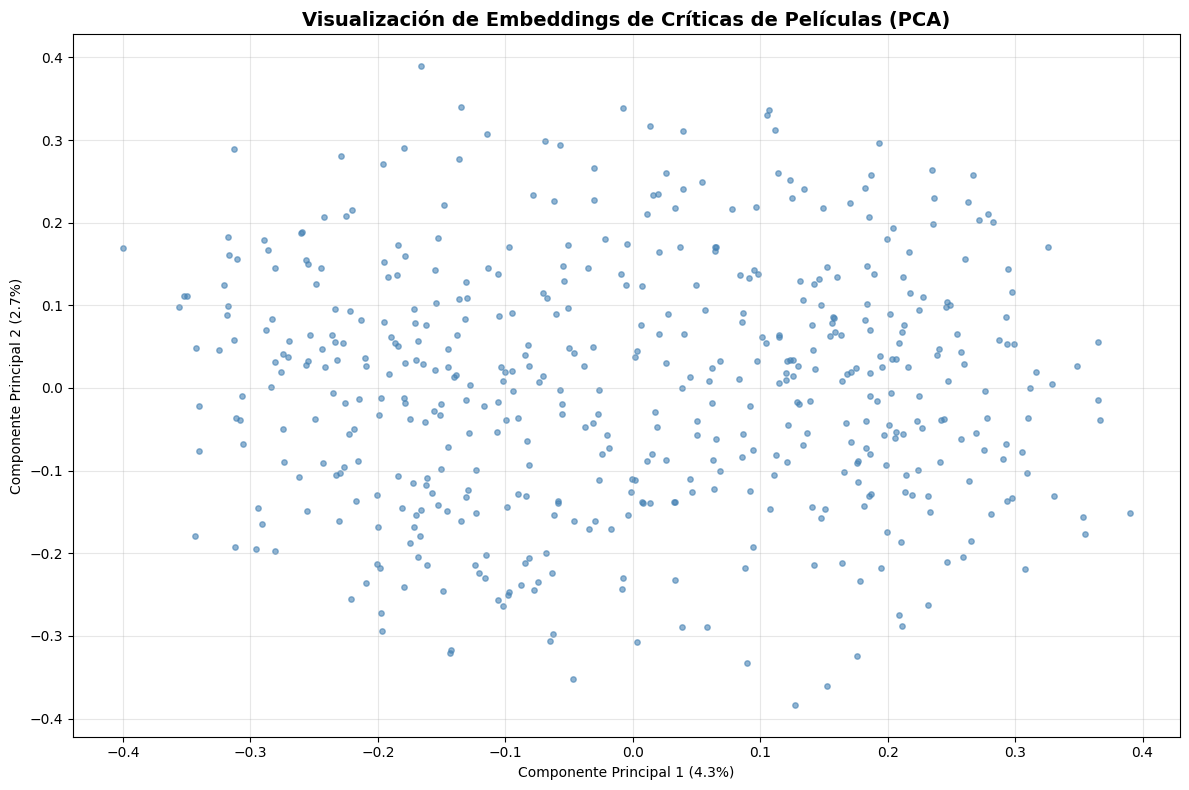


Varianza total explicada: 7.05%
Los documentos similares aparecen agrupados en el espacio vectorial


In [ ]:
print("\n" + "="*100)
print("DESAFÍO DE EXCELENCIA: VISUALIZACIÓN DE EMBEDDINGS CON PCA")
print("="*100)

# Toma 500 documentos aleatorios (para no saturar gráfico)
sample_size = min(500, len(embeddings))
sample_indices = np.random.choice(len(embeddings), sample_size, replace=False)
sample_embeddings = embeddings[sample_indices]

# PCA reduce de 384 a 2 dimensiones (X,Y)
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(sample_embeddings)

# Dibuja puntos en plano cartesiano
plt.figure(figsize=(12, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
            alpha=0.6, s=15, c='steelblue')
plt.title('Visualización de Embeddings de Críticas de Películas (PCA)', 
          fontsize=14, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Muestra qué porcentaje de información conservan las 2 dimensiones
print(f"\nVarianza total explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print("Los documentos similares aparecen agrupados en el espacio vectorial")

# 9. ESTADÍSTICAS FINALES

Estadísticas finales del sistema

In [ ]:
print("\n" + "="*100)
print("ESTADÍSTICAS FINALES DEL SISTEMA")
print("="*100)

print(f"Total de documentos indexados: {len(df)}")  # 9,999 críticas
print(f"Dimensión de los embeddings: {embeddings.shape[1]}")  # 384 dimensiones
print(f"Consultas procesadas: {len(queries)}")  # 8 consultas
print(f"Top-k por consulta: 5")  # 5 resultados por consulta
print(f"Modelo de embeddings: all-MiniLM-L6-v2")   # Modelo usado

# Calcular similitud promedio del top-1
avg_similarity = summary_df['Similitud'].mean()
print(f"Similitud promedio del Top-1: {avg_similarity:.4f}")



ESTADÍSTICAS FINALES DEL SISTEMA
Total de documentos indexados: 9999
Dimensión de los embeddings: 384
Consultas procesadas: 8
Top-k por consulta: 5
Modelo de embeddings: all-MiniLM-L6-v2
Similitud promedio del Top-1: 0.6604
